# Week 14 Execises

## 1

Perform single Euler step
f= function of the derivative x_dot
x= current value of x
t= current time
dt= time step size
returns next value of x after Euler step

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x,t):
    return x

def euler_step(f, x, t, dt):
    return x + dt * f(x, t)

Solve ODE using euler from t0 to t_final with steps no bigger than dtmax
x0 = Initial x
t0 = initial time
t_final = Final time to solve to
dt_max = Maximum time step
Returns arrays containing t and x

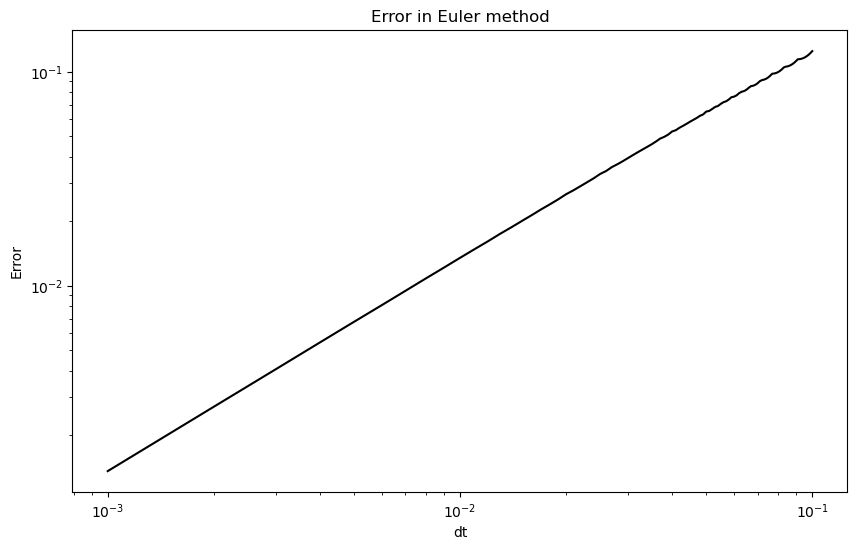

In [2]:
def solve_to(f, x0, t0, t_final, dt_max):
    x = [x0]
    t = [t0]
    while t[-1]< t_final:
        dt = min(dt_max, t_final - t[-1])
        x_new = euler_step(f, x[-1], t[-1], dt)
        x.append(x_new)
        t.append(t[-1] + dt)
    return np.array(t), np.array(x)

def true_solution(t):
    return np.exp(t)

x0 = 1.0
t0 = 0.0
t_final = 1.0

dt_values = np.linspace(0.1, 0.001, 100)

errors = []
for dt in dt_values:
    t, x = solve_to(f, x0, t0, t_final, dt)
    error = np.abs(x[-1] - true_solution(t_final))
    errors.append(error)

plt.figure(figsize=(10,6))
plt.loglog(dt_values, errors, 'k')
plt.xlabel('dt')
plt.ylabel('Error')
plt.title('Error in Euler method')
plt.show()





## 2

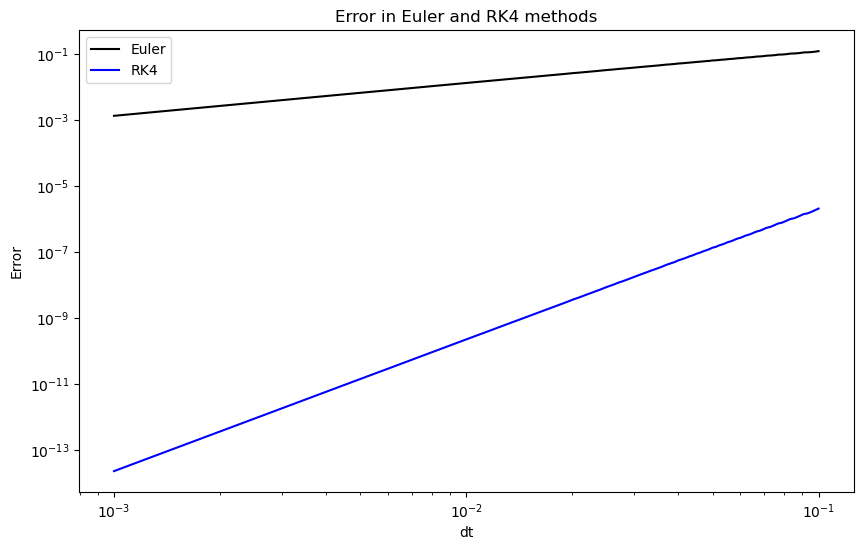

In [3]:
def rk4_step(f, x, t, dt):
    k1 = dt * f(x, t)
    k2 = dt * f(x + 0.5*k1, t + 0.5*dt)
    k3 = dt * f(x + 0.5*k2, t + 0.5*dt)
    k4 = dt * f(x + k3, t + dt)
    return x + (k1 + 2*k2 + 2*k3 + k4)/6

def solve_to(f, x0, t0, t_final, dt_max, method='euler'):
    x = [x0]
    t = [t0]
    while t[-1]< t_final:
        dt = min(dt_max, t_final - t[-1])
        if method == 'euler':
            x_new = euler_step(f, x[-1], t[-1], dt)
        elif method == 'rk4':
            x_new = rk4_step(f, x[-1], t[-1], dt)
        x.append(x_new)
        t.append(t[-1] + dt)
    return np.array(t), np.array(x)

errors_rk4 = []
for dt in dt_values:
    t, x = solve_to(f, x0, t0, t_final, dt, method='rk4')
    error = np.abs(x[-1] - true_solution(t_final))
    errors_rk4.append(error)

plt.figure(figsize=(10,6))
plt.loglog(dt_values, errors, 'k', label='Euler')
plt.loglog(dt_values, errors_rk4, 'b', label='RK4')
plt.xlabel('dt')
plt.ylabel('Error')
plt.title('Error in Euler and RK4 methods')
plt.legend()
plt.show()



In [4]:
import time
t0 = time.time()
t, x = solve_to(f, x0, t0, t_final, 0.0001, method='euler')
t1 = time.time()
print('Euler method: ', t1-t0)

t0 = time.time()
t, x = solve_to(f, x0, t0, t_final, 0.0001, method='rk4')
t1 = time.time()
print('RK4 method: ', t1-t0)



Euler method:  6.508827209472656e-05
RK4 method:  6.794929504394531e-05


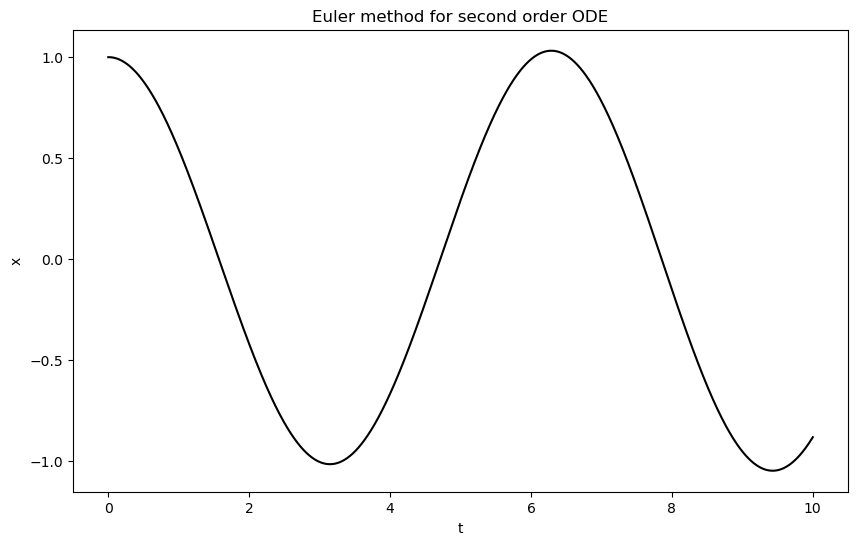

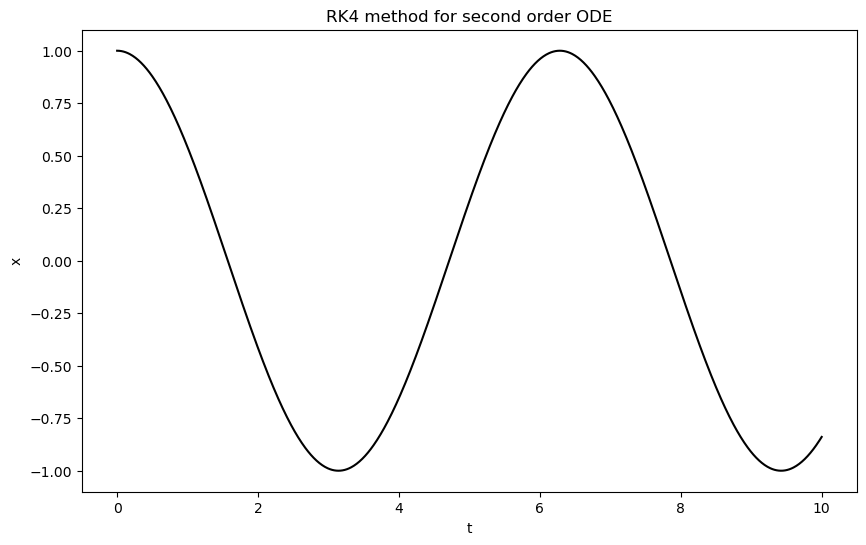

In [5]:
def f(x, t):
    return np.array([x[1], -x[0]])

t, x = solve_to(f, np.array([1.0, 0.0]), 0.0, 10.0, 0.01, method='euler')
plt.figure(figsize=(10,6))
plt.plot(t, x[:,0], 'k')
plt.xlabel('t')
plt.ylabel('x')
plt.title('Euler method for second order ODE')
plt.show()

t, x = solve_to(f, np.array([1.0, 0.0]), 0.0, 10.0, 0.01, method='rk4')
plt.figure(figsize=(10,6))
plt.plot(t, x[:,0], 'k')
plt.xlabel('t')
plt.ylabel('x')
plt.title('RK4 method for second order ODE')
plt.show()

### What should true solutions be?
True solutions should be x = cos(t) and y = -sin(t)

### What goes wrong with the numerical solutions if you run them over a large range of t?
The numerical solutions diverge from the true solutions. This is because the error in the numerical solutions is cumulative, and so grows with time. This is known as numerical instability.

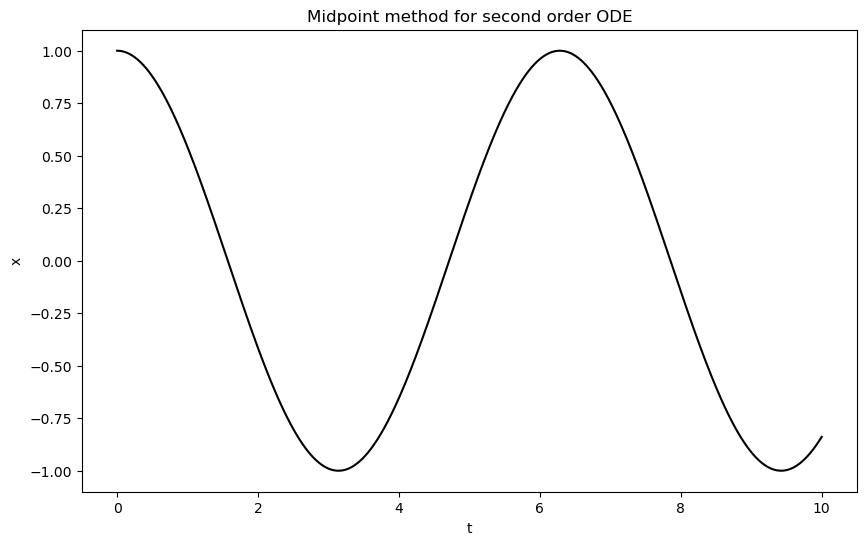

In [6]:
def midpoint_step(f, x, t, dt):
    k1 = dt * f(x, t)
    k2 = dt * f(x + 0.5*k1, t + 0.5*dt)
    return x + k2

def solve_to(f, x0, t0, t_final, dt_max, method='euler'):
    x = [x0]
    t = [t0]
    while t[-1]< t_final:
        dt = min(dt_max, t_final - t[-1])
        if method == 'euler':
            x_new = euler_step(f, x[-1], t[-1], dt)
        elif method == 'rk4':
            x_new = rk4_step(f, x[-1], t[-1], dt)
        elif method == 'midpoint':
            x_new = midpoint_step(f, x[-1], t[-1], dt)
        x.append(x_new)
        t.append(t[-1] + dt)
    return np.array(t), np.array(x)

t, x = solve_to(f, np.array([1.0, 0.0]), 0.0, 10.0, 0.01, method='midpoint')
plt.figure(figsize=(10,6))
plt.plot(t, x[:,0], 'k')
plt.xlabel('t')
plt.ylabel('x')
plt.title('Midpoint method for second order ODE')
plt.show()
